In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv('Downloads/morgan_stanely.csv')
# copied data into another variable so that original data remains unaffected
dt=data.copy()
dt.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,06-01-2023,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,17-02-2023,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,13-09-2023,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,28-05-2024,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,12-05-2023,77104.456470,57425.69930,1.042441,393,10


# Task 1: Data Cleaning and Formatting


In [3]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB


In [4]:
dt.describe()

,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,99.786250,55194.889273,72764.355699,0.473380,568.526250,119.870000
std,57.460793,28940.337792,35623.574024,0.239982,155.620111,67.356806
min,1.000000,-36173.695550,-62548.722060,-0.300118,306.000000,6.000000
25%,50.000000,34842.164247,48684.199043,0.312271,437.000000,63.000000
50%,99.500000,53768.493325,72908.053070,0.485829,565.000000,118.000000
75%,150.000000,74729.551358,95574.572673,0.632799,699.500000,178.000000
max,199.000000,154662.045800,180539.287700,1.254704,848.000000,238.000000


## changing the columns name so that i can work with them easily ##

In [5]:
dt.columns

Index(['TransactionID', 'CustomerID', 'AccountID', 'AccountType',
       'TransactionType', 'Product', 'Firm', 'Region', 'Manager',
       'TransactionDate', 'TransactionAmount', 'AccountBalance', 'RiskScore',
       'CreditRating', 'TenureMonths'],
      dtype='object')

In [6]:
dt=dt.rename(columns={'TransactionID':'transaction_id', 'CustomerID':'customer_id', 'AccountID':'account_id', 'AccountType':'account_type',
       'TransactionType':'transaction_type', 'Product':'product', 'Firm':'firm', 'Region':'region', 'Manager':'manager',
       'TransactionDate':'transaction_date', 'TransactionAmount':'transaction_amount', 'AccountBalance':'account_balance', 'RiskScore':'risk_score',
       'CreditRating':'credit_rating', 'TenureMonths':'tenure_month'})

In [7]:
dt.columns

Index(['transaction_id', 'customer_id', 'account_id', 'account_type',
       'transaction_type', 'product', 'firm', 'region', 'manager',
       'transaction_date', 'transaction_amount', 'account_balance',
       'risk_score', 'credit_rating', 'tenure_month'],
      dtype='object')

## checking null values

In [8]:
dt.isna().sum()

transaction_id        0
customer_id           0
account_id            0
account_type          0
transaction_type      0
product               0
firm                  0
region                0
manager               0
transaction_date      0
transaction_amount    0
account_balance       0
risk_score            0
credit_rating         0
tenure_month          0
dtype: int64

***there are no null values in data***

## insuring there are no duplicates

In [9]:
dt[dt.duplicated()]

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month


In [10]:
dt.duplicated().sum()

np.int64(0)

***there are no duplicate values in data***

## changing transaction date format to datetime from string

In [11]:
dt.transaction_date

0      06-01-2023
1      17-02-2023
2      13-09-2023
3      28-05-2024
4      12-05-2023
          ...    
795    01-01-2024
796    12-05-2023
797    22-03-2024
798    21-03-2024
799    29-01-2024
Name: transaction_date, Length: 800, dtype: object

In [12]:
dt.transaction_date=pd.to_datetime(dt['transaction_date'],format='%d-%m-%Y')

In [13]:
dt.transaction_date.dtype

dtype('<M8[ns]')

In [14]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      800 non-null    int64         
 1   customer_id         800 non-null    object        
 2   account_id          800 non-null    object        
 3   account_type        800 non-null    object        
 4   transaction_type    800 non-null    object        
 5   product             800 non-null    object        
 6   firm                800 non-null    object        
 7   region              800 non-null    object        
 8   manager             800 non-null    object        
 9   transaction_date    800 non-null    datetime64[ns]
 10  transaction_amount  800 non-null    float64       
 11  account_balance     800 non-null    float64       
 12  risk_score          800 non-null    float64       
 13  credit_rating       800 non-null    int64         

# Task 2: Descriptive Transactional Analysis

In [15]:
dt.head(10)

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
5,97,CUST1467,ACC65144,Savings,Transfer,Personal Loan,Firm C,North,Manager 1,2023-12-10,18727.127840,86727.62188,0.250873,550,229
6,76,CUST3187,ACC72197,Savings,Deposit,Mutual Fund,Firm B,South,Manager 4,2024-02-17,28719.955920,32349.20862,0.687498,465,152
7,188,CUST9528,ACC25132,Savings,Withdrawal,Savings Account,Firm D,West,Manager 2,2023-07-30,43770.677920,46525.22852,0.872795,703,82
8,84,CUST3810,ACC43771,Credit,Payment,Credit Card,Firm A,South,Manager 3,2023-12-21,64084.081250,154875.43370,0.534973,386,163
9,13,CUST2805,ACC19178,Credit,Payment,Credit Card,Firm D,West,Manager 3,2024-02-17,138133.821600,58667.17647,0.386822,747,126


#### analysis of transactions

### Calculate monthly and yearly summaries of total credits, debits, and net transaction volume. 

In [16]:
dt.transaction_type.unique()

array(['Withdrawal', 'Transfer', 'Payment', 'Deposit'], dtype=object)

In [17]:
monthly_avg_txn = dt.groupby([dt['transaction_date'].dt.to_period('M').rename('month'),dt.transaction_type])[['transaction_amount']].mean()
monthly_avg_txn=pd.DataFrame(monthly_avg_txn)
monthly_avg_txn=monthly_avg_txn.reset_index()
monthly_avg_txn['month']=monthly_avg_txn['month'].dt.strftime('%m-%Y')
monthly_avg_txn

,month,transaction_type,transaction_amount
0,01-2023,Deposit,52830.543720
1,01-2023,Payment,50207.635529
2,01-2023,Transfer,58897.421853
3,01-2023,Withdrawal,48251.391094
4,02-2023,Deposit,47971.592740
...,...,...,...
67,05-2024,Withdrawal,60578.722696
68,06-2024,Deposit,40815.830004
69,06-2024,Payment,62841.708896
70,06-2024,Transfer,59173.173933


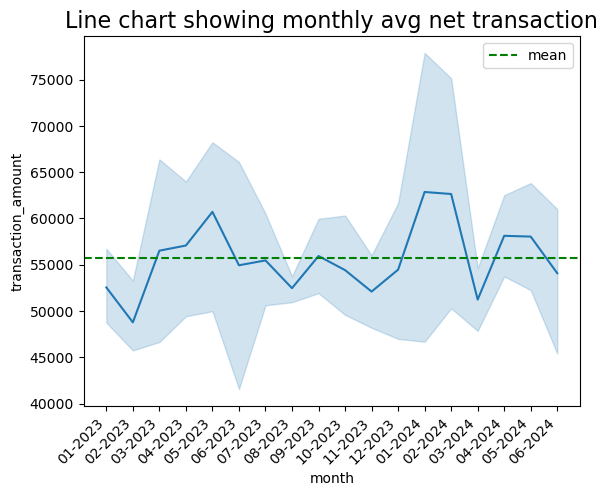

In [18]:
sns.lineplot(data=monthly_avg_txn,x='month', y='transaction_amount')
plt.xticks(rotation=45, horizontalalignment='right')
plt.axhline(y=monthly_avg_txn['transaction_amount'].mean(),color='green',ls='--',label='mean')
plt.title('Line chart showing monthly avg net transaction',fontsize=16)
plt.legend()
plt.show()

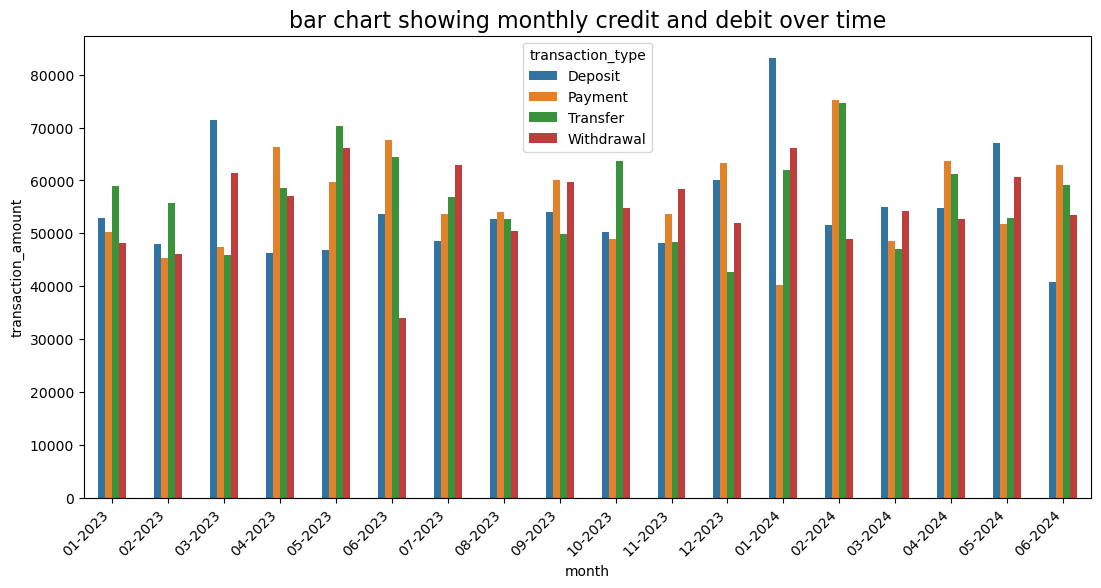

In [19]:
plt.figure(figsize=(13,6))
sns.barplot(data=monthly_avg_txn,x='month', y='transaction_amount',width=0.5,hue='transaction_type')
plt.xticks(rotation=45, horizontalalignment='right')
plt.title('bar chart showing monthly credit and debit over time',fontsize=16);

### top and bottom preforming account based on net inflow

In [20]:
inflow_df=dt[dt['transaction_type']=='Deposit']
inflow_df

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
6,76,CUST3187,ACC72197,Savings,Deposit,Mutual Fund,Firm B,South,Manager 4,2024-02-17,28719.955920,32349.20862,0.687498,465,152
10,140,CUST6735,ACC83848,Current,Deposit,Mutual Fund,Firm E,Central,Manager 3,2023-01-10,32006.025600,57622.88289,0.560802,453,182
11,16,CUST6391,ACC25132,Current,Deposit,Home Loan,Firm A,South,Manager 4,2024-03-02,74244.980120,135851.46530,0.382191,753,151
12,21,CUST6837,ACC82381,Credit,Deposit,Credit Card,Firm E,South,Manager 4,2023-04-09,53635.689280,99074.60346,0.497149,503,177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,91,CUST7345,ACC18177,Loan,Deposit,Savings Account,Firm E,South,Manager 3,2023-09-26,68223.014320,76117.15722,0.428730,715,32
775,30,CUST3187,ACC65144,Loan,Deposit,Credit Card,Firm B,South,Manager 3,2024-03-28,111130.299000,121200.93760,0.603603,532,123
781,195,CUST2349,ACC18057,Loan,Deposit,Mutual Fund,Firm C,East,Manager 2,2023-08-18,7531.594658,149223.55970,0.373717,614,59
782,8,CUST3187,ACC22799,Credit,Deposit,Personal Loan,Firm E,West,Manager 2,2024-01-17,16579.281170,103789.99400,0.602145,428,198


In [21]:
account_inflow=inflow_df.groupby('account_id')[['transaction_amount']].sum().sort_values(by='transaction_amount',ascending=False).reset_index()

#### top performing accounts in term of inflow

In [22]:
top_inflow = account_inflow.head()
top_inflow

,account_id,transaction_amount
0,ACC48501,323846.55886
1,ACC10996,254968.10439
2,ACC77773,252046.75562
3,ACC57700,250121.85850
4,ACC38559,219919.51623


In [23]:
top_inflow.describe()

,transaction_amount
count,5.000000
mean,260180.558720
std,38304.102259
min,219919.516230
25%,250121.858500
50%,252046.755620
75%,254968.104390
max,323846.558860


####  bottom performing accounts in term of inflow

In [24]:
bottom_inflow = account_inflow.tail()
bottom_inflow

,account_id,transaction_amount
116,ACC28612,16937.678890
117,ACC87006,14600.979200
118,ACC94242,9780.217571
119,ACC18057,7531.594658
120,ACC49364,-11539.756300


In [25]:
bottom_inflow.describe()

,transaction_amount
count,5.000000
mean,7462.142804
std,11260.542093
min,-11539.756300
25%,7531.594658
50%,9780.217571
75%,14600.979200
max,16937.678890


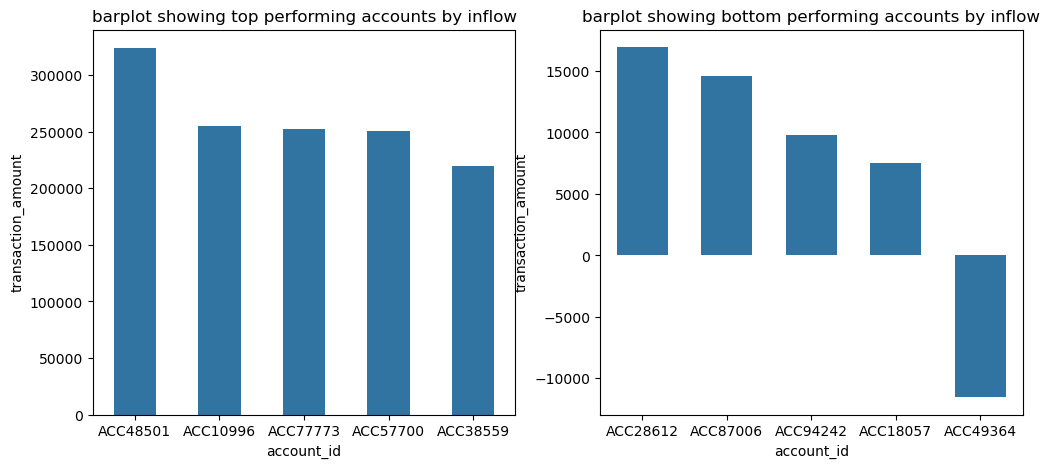

In [26]:
fig, ax =plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=top_inflow,x='account_id', y='transaction_amount',width=0.5 ,ax=ax[0])
sns.barplot(data=bottom_inflow,x='account_id', y='transaction_amount',width=0.6 ,ax=ax[1])
ax[0].set_title('barplot showing top performing accounts by inflow')
ax[1].set_title('barplot showing bottom performing accounts by inflow')
plt.show()

### dormant accounts

In [27]:
# shorting the data based on account id and transaction sate
date_sort=dt[['account_id','transaction_date']].sort_values(by=['account_id', 'transaction_date'])
date_sort

,account_id,transaction_date
58,ACC10117,2023-01-30
555,ACC10117,2023-04-30
509,ACC10117,2023-06-20
696,ACC10117,2023-07-14
727,ACC10117,2023-08-04
...,...,...
518,ACC99549,2023-06-06
231,ACC99549,2023-07-19
563,ACC99549,2024-02-04
67,ACC99549,2024-02-21


In [28]:
# calculate the diff between the transaction date and selecting account with more than 60 inactive days
date_sort['days_last_txn']=date_sort.groupby('account_id')['transaction_date'].diff().dt.days
dormant_accounts=date_sort[date_sort['days_last_txn']>=60]
dormant_accounts

,account_id,transaction_date,days_last_txn
555,ACC10117,2023-04-30,90.0
753,ACC10117,2024-02-05,128.0
3,ACC10117,2024-05-28,100.0
137,ACC10996,2023-08-17,116.0
515,ACC10996,2023-10-26,70.0
...,...,...,...
113,ACC96868,2024-06-11,66.0
134,ACC97411,2023-11-25,323.0
201,ACC99117,2024-05-22,252.0
444,ACC99409,2024-03-14,409.0


as we can see that an account has never been completely inactive, these account are becoming active and inactive in differrent time periods, 
for example if we see ACC10117 it has been inactive 3 times , but it was active aswell between(apart from) this times periods

In [29]:
# calculating the how many time an account has been inactive
dormant_time=dormant_accounts.value_counts('account_id').reset_index()
dormant_time

,account_id,count
0,ACC65144,5
1,ACC77592,5
2,ACC16664,5
3,ACC51009,4
4,ACC48501,4
...,...,...
162,ACC51200,1
163,ACC18140,1
164,ACC49422,1
165,ACC49395,1


In [30]:
# calculating which count appears more frequently
dormant_counts=dormant_time['count'].value_counts()
dormant_counts

count
1    63
2    62
3    32
4     7
5     3
Name: count, dtype: int64

***there are 63 accounts which has been  inactive for once, 62 accounts has been inactive for two times, and so on***

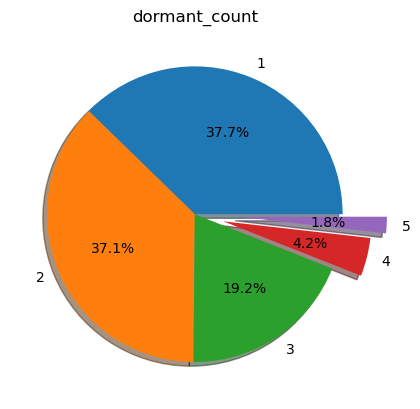

In [31]:
plt.pie(dormant_counts,autopct='%0.1F%%',labels=dormant_counts.index,explode=[0,0,0,0.2,0.3],shadow=True)
plt.title('dormant_count')
plt.show()

1.8% accounts have been inactive for 5 times and 37% account have been inactive for 1 time

# Task 3 : Customer Profile Building

In [32]:
dt

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30


## Group accounts by activity levels:

In [33]:
# frequency of transaction by each account
frequency_dt=dt.groupby('account_id')[['account_id']].count()
frequency_dt=frequency_dt['account_id'].rename('frequency').reset_index()
frequency_dt

,account_id,frequency
0,ACC10117,9
1,ACC10996,8
2,ACC11062,4
3,ACC11188,2
4,ACC11285,5
...,...,...
184,ACC96868,5
185,ACC97411,4
186,ACC99117,2
187,ACC99409,2


In [34]:
frequency_dt.describe()

,frequency
count,189.000000
mean,4.232804
std,2.322137
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,13.000000


as we can see that 75 precentile of data is 6, 50% is 4, if frequency is more than 6 then category is high , if frequency is between 4 and 6 then 
category is mid and if it is below 4 than category is low

In [35]:
# as we can see that 75 precentile of data is 6, 50% is 4, 
# if frequency is more than 6 then category is high , 
#if frequency is between 4 and 6 then  category is mid
# and if it is below 4 than category is low

def category(freq):
    if freq >6:
        return 'high'
    elif freq >= 4:
        return 'mid'
    else:
        return 'low'


In [36]:
frequency_dt['freq_category'] = frequency_dt['frequency'].apply(category)

In [37]:
frequency_dt

,account_id,frequency,freq_category
0,ACC10117,9,high
1,ACC10996,8,high
2,ACC11062,4,mid
3,ACC11188,2,low
4,ACC11285,5,mid
...,...,...,...
184,ACC96868,5,mid
185,ACC97411,4,mid
186,ACC99117,2,low
187,ACC99409,2,low


In [38]:
freq_count=frequency_dt.value_counts('freq_category')
freq_count

freq_category
low     86
mid     72
high    31
Name: count, dtype: int64

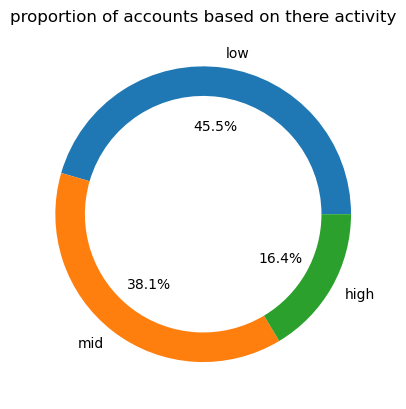

In [39]:
plt.pie(freq_count, autopct='%0.1f%%',labels=freq_count.index,wedgeprops=dict(width=0.2))
plt.title('proportion of accounts based on there activity');

## segmentation of accounts based on there avg account balance

In [40]:
avg_balance = dt.groupby('account_id')[['account_balance']].mean().round(2).reset_index()
avg_balance

,account_id,account_balance
0,ACC10117,94082.59
1,ACC10996,72517.76
2,ACC11062,73541.33
3,ACC11188,51359.04
4,ACC11285,79923.62
...,...,...
184,ACC96868,73833.95
185,ACC97411,32190.91
186,ACC99117,110239.79
187,ACC99409,33525.39


In [41]:
avg_balance.describe()

,account_balance
count,189.000000
mean,71960.645661
std,18605.231122
min,7017.440000
25%,59999.270000
50%,72852.560000
75%,84621.310000
max,117133.780000


as we can see that 75 precentile of data is 84621, 50% is 72852, 
if account_balance is more than 84621 then category is high , 
if account_balance is between 72852 and 84621 then category is mid 
and if account_balance is below 72852 than category is low



In [42]:
#as we can see that 75 precentile of data is 84621, 50% is 72852, 
#if account_balance is more than 84621 then category is high , 
#if account_balance is between 72852 and 84621 then category is mid 
#and if account_balance is below 72852 than category is low



def bal_category(balance):
    if balance >84621:
        return 'high'
    elif balance >= 72852:
        return 'mid'
    else:
        return 'low'

In [43]:
avg_balance['bal_category'] = avg_balance['account_balance'].apply(bal_category)

In [44]:
avg_balance

,account_id,account_balance,bal_category
0,ACC10117,94082.59,high
1,ACC10996,72517.76,low
2,ACC11062,73541.33,mid
3,ACC11188,51359.04,low
4,ACC11285,79923.62,mid
...,...,...,...
184,ACC96868,73833.95,mid
185,ACC97411,32190.91,low
186,ACC99117,110239.79,high
187,ACC99409,33525.39,low


In [45]:
count_bal_category=avg_balance.value_counts('bal_category')
count_bal_category

bal_category
low     94
high    48
mid     47
Name: count, dtype: int64

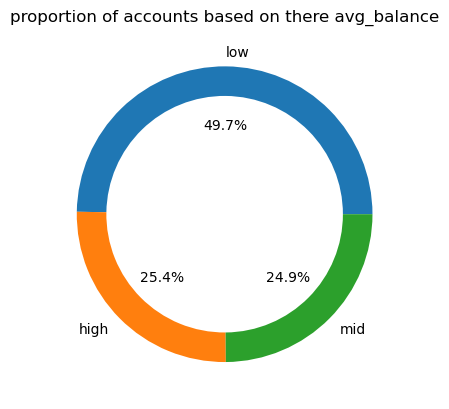

In [46]:
plt.pie(count_bal_category, autopct='%0.1f%%',labels=count_bal_category.index,wedgeprops=dict(width=0.2))
plt.title('proportion of accounts based on there avg_balance');

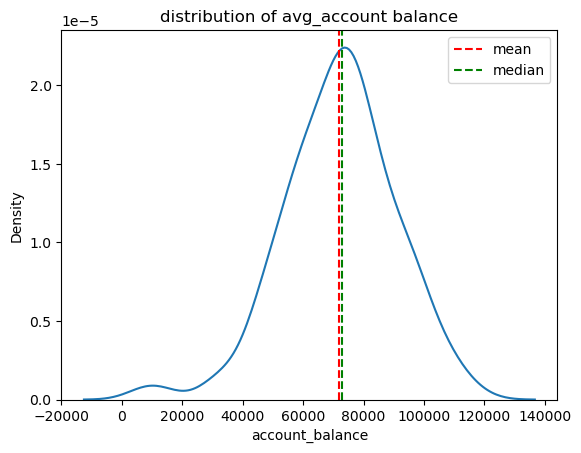

In [47]:
sns.kdeplot(data=avg_balance,x='account_balance')
plt.axvline(x=avg_balance['account_balance'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=avg_balance['account_balance'].median(),color='green',ls='--',label='median')
plt.title('distribution of avg_account balance')
plt.legend();

In [48]:
avg_balance['account_balance'].skew()

np.float64(-0.4391226548574028)

## segmentation of accounts based on there transaction volume

In [49]:
txn_volume=dt.groupby('account_id')['transaction_amount'].sum().round().reset_index()
txn_volume

,account_id,transaction_amount
0,ACC10117,599629.0
1,ACC10996,506746.0
2,ACC11062,247384.0
3,ACC11188,127635.0
4,ACC11285,169319.0
...,...,...
184,ACC96868,317559.0
185,ACC97411,304243.0
186,ACC99117,116277.0
187,ACC99409,60447.0


In [50]:
txn_volume.describe()

,transaction_amount
count,189.000000
mean,233629.179894
std,142746.441162
min,20126.000000
25%,133938.000000
50%,203367.000000
75%,289388.000000
max,813651.000000


as we can see that 75 precentile of data is 289388, 50% is 203367, if transaction_amount is more than 289388 then category is high , if transaction_amount is between 203367 and 289388 then category is mid and if transaction_amount is below 203367 than category is low

In [51]:
def txn_category(txn):
    if txn >289388:
        return 'high'
    elif txn >= 203367:
        return 'mid'
    else:
        return 'low'

In [52]:
txn_volume['category']= txn_volume['transaction_amount'].apply(txn_category)

In [53]:
txn_volume

,account_id,transaction_amount,category
0,ACC10117,599629.0,high
1,ACC10996,506746.0,high
2,ACC11062,247384.0,mid
3,ACC11188,127635.0,low
4,ACC11285,169319.0,low
...,...,...,...
184,ACC96868,317559.0,high
185,ACC97411,304243.0,high
186,ACC99117,116277.0,low
187,ACC99409,60447.0,low


In [54]:
count_txn_vol_category=txn_volume.value_counts('category')
count_txn_vol_category

category
low     94
mid     48
high    47
Name: count, dtype: int64

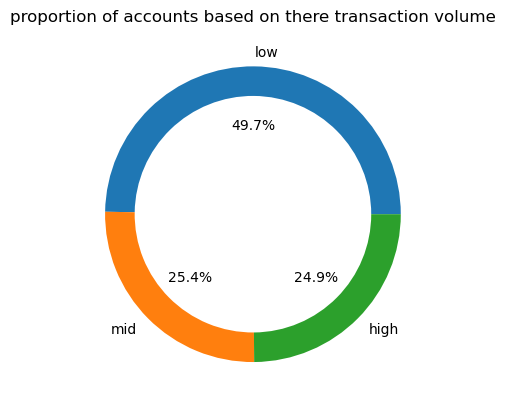

In [55]:
plt.pie(count_txn_vol_category, autopct='%0.1f%%',labels=count_txn_vol_category.index,wedgeprops=dict(width=0.2))
plt.title('proportion of accounts based on there transaction volume');

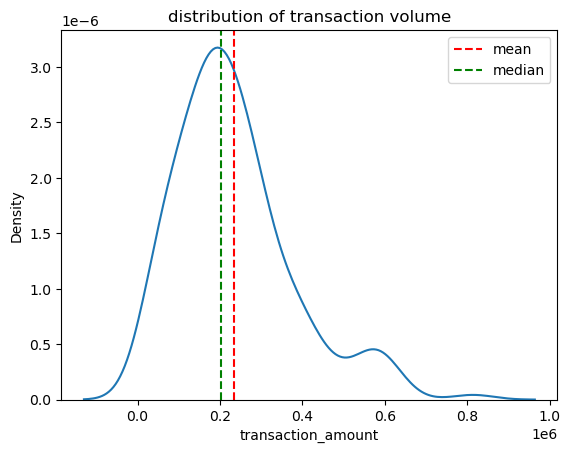

In [56]:
sns.kdeplot(data=txn_volume, x='transaction_amount')
plt.axvline(x=txn_volume['transaction_amount'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=txn_volume['transaction_amount'].median(),color='green',ls='--',label='median')
plt.title('distribution of transaction volume')
plt.legend()
plt.show()

In [57]:
txn_volume['transaction_amount'].skew()

np.float64(1.1284776343403584)

## High net inflow accounts

In [58]:
dt.transaction_amount.describe()

count       800.000000
mean      55194.889273
std       28940.337792
min      -36173.695550
25%       34842.164247
50%       53768.493325
75%       74729.551358
max      154662.045800
Name: transaction_amount, dtype: float64

In [59]:
inflow=dt[(dt['transaction_type']=='Deposit')]
inflow

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
6,76,CUST3187,ACC72197,Savings,Deposit,Mutual Fund,Firm B,South,Manager 4,2024-02-17,28719.955920,32349.20862,0.687498,465,152
10,140,CUST6735,ACC83848,Current,Deposit,Mutual Fund,Firm E,Central,Manager 3,2023-01-10,32006.025600,57622.88289,0.560802,453,182
11,16,CUST6391,ACC25132,Current,Deposit,Home Loan,Firm A,South,Manager 4,2024-03-02,74244.980120,135851.46530,0.382191,753,151
12,21,CUST6837,ACC82381,Credit,Deposit,Credit Card,Firm E,South,Manager 4,2023-04-09,53635.689280,99074.60346,0.497149,503,177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,91,CUST7345,ACC18177,Loan,Deposit,Savings Account,Firm E,South,Manager 3,2023-09-26,68223.014320,76117.15722,0.428730,715,32
775,30,CUST3187,ACC65144,Loan,Deposit,Credit Card,Firm B,South,Manager 3,2024-03-28,111130.299000,121200.93760,0.603603,532,123
781,195,CUST2349,ACC18057,Loan,Deposit,Mutual Fund,Firm C,East,Manager 2,2023-08-18,7531.594658,149223.55970,0.373717,614,59
782,8,CUST3187,ACC22799,Credit,Deposit,Personal Loan,Firm E,West,Manager 2,2024-01-17,16579.281170,103789.99400,0.602145,428,198


In [60]:
## avg inflow of every account
avg_inflow=inflow.groupby('account_id')['transaction_amount'].mean().reset_index()
avg_inflow

,account_id,transaction_amount
0,ACC10117,52336.342780
1,ACC10996,84989.368130
2,ACC11837,73780.249030
3,ACC12334,24950.858716
4,ACC13357,43879.608440
...,...,...
116,ACC95164,54632.753515
117,ACC95774,53006.641783
118,ACC96868,52559.705175
119,ACC97411,48958.410710


In [61]:
avg_inflow.describe()

,transaction_amount
count,121.000000
mean,54205.107291
std,24262.410599
min,-11539.756300
25%,37160.173930
50%,52888.189510
75%,67650.191195
max,144137.880300


#### 75% of the account has below 67650 avg inflow, so taking this as a refrence for high inflow,taking out all the accounts where avg infolw is 
#### more than 67650

In [62]:
account_with_high_net_inflow = avg_inflow[avg_inflow['transaction_amount']>67650]
print(len(account_with_high_net_inflow))
account_with_high_net_inflow

31


,account_id,transaction_amount
1,ACC10996,84989.368130
2,ACC11837,73780.249030
6,ACC15359,78950.074540
8,ACC15925,71686.400650
14,ACC21264,77499.730060
17,ACC21878,69626.633210
28,ACC29396,84074.769530
31,ACC31539,75468.624880
41,ACC39161,77271.012360
45,ACC40939,72431.646660


### high frequency low balance account

In [63]:
freq_bal=dt.groupby('account_id').agg(frequency=('account_id','count'),avg_balance=('account_balance','mean')).reset_index()
freq_bal

,account_id,frequency,avg_balance
0,ACC10117,9,94082.590727
1,ACC10996,8,72517.761136
2,ACC11062,4,73541.328302
3,ACC11188,2,51359.039950
4,ACC11285,5,79923.619870
...,...,...,...
184,ACC96868,5,73833.947050
185,ACC97411,4,32190.912745
186,ACC99117,2,110239.787525
187,ACC99409,2,33525.389300


In [64]:
freq_bal.describe()

,frequency,avg_balance
count,189.000000,189.000000
mean,4.232804,71960.646262
std,2.322137,18605.231167
min,1.000000,7017.436865
25%,2.000000,59999.271894
50%,4.000000,72852.561447
75%,6.000000,84621.307018
max,13.000000,117133.776550


In [65]:
high_freq_low_bal_accounts=freq_bal[(freq_bal['frequency']>6) & (freq_bal['avg_balance']<59999)]
high_freq_low_bal_accounts

,account_id,frequency,avg_balance
32,ACC24508,7,57275.485464
47,ACC29231,7,54530.479503
98,ACC50817,7,59021.066076


above are the account where frequency is more than the 75 percentile of the data but avg_balance is below 25 percentile of the data

###  Accounts with negative or near-zero balances 


In [66]:
account_less_than_or_near_zero_balance=dt[dt['account_balance']<1][['account_id','account_balance']]
print(len(account_less_than_or_near_zero_balance))
account_less_than_or_near_zero_balance

21


,account_id,account_balance
158,ACC26940,-22668.046670
224,ACC48501,-6629.775977
237,ACC89098,-5909.198808
253,ACC34431,-6111.634329
350,ACC17688,-6998.284258
391,ACC18177,-6158.757250
398,ACC60432,-2466.768368
401,ACC77773,-2427.573420
416,ACC32212,-28676.452550
417,ACC50817,-6314.634095


# *Task 4: Financial Risk Identification*

## accounts with frequent large withdrawals or overdrafts.

In [67]:
dt

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30


In [68]:
# fetching only withdrawl transactions
withdwawal_txn = dt[dt['transaction_type']=='Withdrawal']
withdwawal_txn

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
7,188,CUST9528,ACC25132,Savings,Withdrawal,Savings Account,Firm D,West,Manager 2,2023-07-30,43770.677920,46525.22852,0.872795,703,82
14,54,CUST5705,ACC39161,Credit,Withdrawal,Credit Card,Firm C,South,Manager 2,2023-12-17,31022.927270,98433.75806,0.556357,757,166
19,36,CUST1747,ACC73104,Savings,Withdrawal,Mutual Fund,Firm C,West,Manager 1,2024-03-21,23118.067060,98758.66658,0.835287,401,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,98,CUST6082,ACC23736,Credit,Withdrawal,Personal Loan,Firm B,West,Manager 4,2023-07-25,52123.002160,59373.86338,0.945191,699,212
779,146,CUST9066,ACC42903,Savings,Withdrawal,Mutual Fund,Firm E,East,Manager 3,2024-04-25,26537.563460,123305.47960,0.529688,606,149
787,106,CUST4884,ACC32627,Credit,Withdrawal,Personal Loan,Firm A,North,Manager 3,2023-02-23,104984.411400,45585.55578,0.605593,824,209
790,65,CUST8390,ACC28295,Current,Withdrawal,Savings Account,Firm E,North,Manager 1,2024-04-25,15827.705760,39205.20833,0.712485,737,190


In [69]:
withdwawal_txn['transaction_amount'].describe()

count       203.000000
mean      54708.676736
std       27942.054635
min      -18353.156470
25%       35987.775575
50%       53636.577690
75%       74047.984975
max      122296.217300
Name: transaction_amount, dtype: float64

In [70]:
# taking 75 percentile as large amount
large_withdrawl=withdwawal_txn[withdwawal_txn['transaction_amount']>74047]
print(len(large_withdrawl))
large_withdrawl

51


,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.42519,40843.561930,0.330474,484,13
29,188,CUST6319,ACC66190,Credit,Withdrawal,Home Loan,Firm B,South,Manager 1,2023-02-23,76960.52529,113504.454800,0.641750,666,9
47,185,CUST1497,ACC21264,Credit,Withdrawal,Savings Account,Firm C,South,Manager 1,2023-11-19,106306.42830,21894.588070,0.794521,728,130
54,90,CUST8155,ACC15671,Loan,Withdrawal,Credit Card,Firm C,West,Manager 4,2023-08-11,89069.30138,58979.858810,0.802974,631,138
55,163,CUST2612,ACC50817,Loan,Withdrawal,Home Loan,Firm B,North,Manager 3,2023-11-21,110477.43290,49526.505610,0.232656,761,137
60,31,CUST6947,ACC24070,Savings,Withdrawal,Personal Loan,Firm B,West,Manager 2,2024-06-13,106501.55890,124958.779200,0.637557,545,209
88,129,CUST6319,ACC69323,Savings,Withdrawal,Savings Account,Firm A,Central,Manager 4,2024-03-14,79497.48751,66794.152720,0.459432,821,102
109,123,CUST2464,ACC28292,Savings,Withdrawal,Mutual Fund,Firm B,North,Manager 4,2023-07-06,89183.28952,76593.800030,0.636499,437,51
115,15,CUST6549,ACC34431,Current,Withdrawal,Home Loan,Firm D,East,Manager 1,2023-05-12,113664.37350,99260.536620,0.153778,379,201
147,198,CUST6549,ACC64022,Current,Withdrawal,Mutual Fund,Firm B,North,Manager 3,2024-05-02,120752.17180,76358.281050,0.369162,756,164


In [71]:
freq_large_withdrawl=large_withdrawl.groupby('account_id')['account_id'].count().rename('frequency').reset_index()
print(len(freq_large_withdrawl))
freq_large_withdrawl

44


,account_id,frequency
0,ACC10117,2
1,ACC10996,1
2,ACC11285,1
3,ACC11837,1
4,ACC15671,2
5,ACC16664,1
6,ACC19178,1
7,ACC21264,1
8,ACC24070,1
9,ACC24508,1


Above is the frequency of large withdrawal by account_id

### Calculate balance volatility using coefficient of variation.

In [72]:
dt.head()

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10


In [73]:
from scipy.stats import variation

In [74]:
account_var=(dt.groupby('account_id')['account_balance'].apply(variation)*100).round(2).rename('balance_var').reset_index()
account_var

,account_id,balance_var
0,ACC10117,38.12
1,ACC10996,38.74
2,ACC11062,39.84
3,ACC11188,12.48
4,ACC11285,28.64
...,...,...
184,ACC96868,38.82
185,ACC97411,183.42
186,ACC99117,22.48
187,ACC99409,34.51


In [75]:
less_volatile=account_var[account_var['balance_var']<=10]
print(len(less_volatile))
less_volatile

24


,account_id,balance_var
7,ACC12334,8.03
12,ACC15925,0.00
27,ACC22255,9.27
30,ACC23985,0.00
37,ACC26026,3.92
44,ACC28305,0.00
48,ACC29356,8.74
56,ACC31902,1.35
81,ACC43309,4.15
91,ACC49140,0.00


In [76]:
zero_var_accounts = account_var[account_var['balance_var']==0]
print(len(zero_var_accounts))
zero_var_accounts

12


,account_id,balance_var
12,ACC15925,0.0
30,ACC23985,0.0
44,ACC28305,0.0
91,ACC49140,0.0
97,ACC50439,0.0
101,ACC51593,0.0
104,ACC52650,0.0
108,ACC55331,0.0
120,ACC62809,0.0
131,ACC70314,0.0


***these are 24 accounts with less than 10% variation, we may cosider it very less volatile , also there are 12 accunts with 0 volatility rate***

In [77]:
account_var.describe()

,balance_var
count,189.000000
mean,39.559101
std,36.720260
min,0.000000
25%,21.790000
50%,38.820000
75%,49.600000
max,423.020000


***we can see 75% of our account have a coefficient of variation below 50***

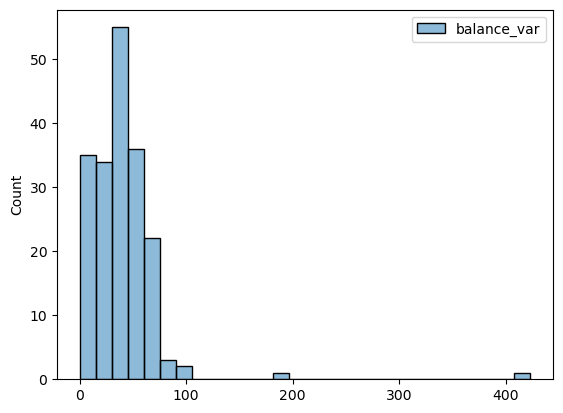

In [78]:
sns.histplot(account_var);

In [79]:
print('coefficient of variation for entire balance column',round(variation(dt['account_balance'])*100,2))

coefficient of variation for entire balance column 48.93


### detect anomalies  by Useing IQR methods


In [80]:
dt.head()

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10


#### transaction amount

In [81]:
quant25=dt['transaction_amount'].quantile(.25)
quant75=dt['transaction_amount'].quantile(.75)
iqr=quant75-quant25
print('IQR',iqr)
upper_limit= quant75 + 1.5*iqr
lower_limit= quant25 - 1.5*iqr
print('upper_limit',upper_limit)
print('lower_limit',lower_limit)
upper_mask=dt['transaction_amount']>upper_limit
lower_mask=dt['transaction_amount']<lower_limit
dt[upper_mask|lower_mask]

IQR 39887.38711000001
upper_limit 134560.63202250004
lower_limit -24988.91641750002


,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
9,13,CUST2805,ACC19178,Credit,Payment,Credit Card,Firm D,West,Manager 3,2024-02-17,138133.82160,58667.17647,0.386822,747,126
161,52,CUST4258,ACC35419,Loan,Transfer,Personal Loan,Firm B,Central,Manager 1,2023-11-07,-36173.69555,24563.76881,0.838911,745,29
370,92,CUST6526,ACC77533,Loan,Transfer,Mutual Fund,Firm D,West,Manager 3,2024-02-17,154662.04580,68845.57535,0.696874,841,62
525,131,CUST4769,ACC92104,Current,Deposit,Mutual Fund,Firm B,East,Manager 1,2024-01-17,144137.88030,45084.92601,0.283584,364,231
533,47,CUST7098,ACC23736,Loan,Payment,Home Loan,Firm E,West,Manager 3,2023-09-28,141210.80340,94186.76562,0.885864,624,19


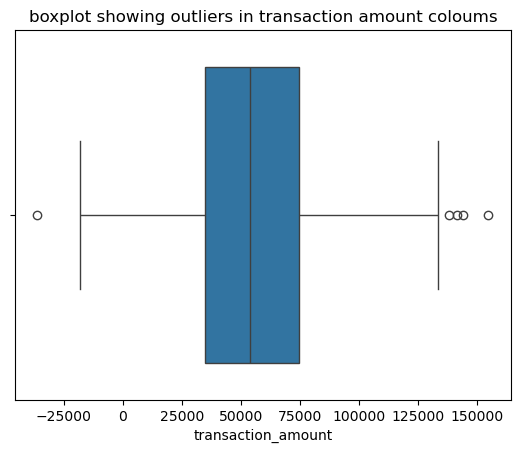

In [82]:
sns.boxplot(data= dt, x='transaction_amount')
plt.title('boxplot showing outliers in transaction amount coloums');

In [83]:
def outliers(col:str):
    quant25=dt[col].quantile(.25)
    quant75=dt[col].quantile(.75)
    iqr=quant75-quant25
    print('IQR',iqr)
    upper_limit= quant75 + 1.5*iqr
    lower_limit= quant25 - 1.5*iqr
    print('upper_limit',upper_limit)
    print('lower_limit',lower_limit)
    upper_mask=dt[col]>upper_limit
    lower_mask=dt[col]<lower_limit
    print('NO. of outliers in',col,' = ',len(dt[upper_mask|lower_mask]))
    sns.boxplot(data=dt,x=col)
    plt.show()
    return dt[upper_mask|lower_mask]
    sns.histplot(data=dt,x=col)
    plt.show()

### Account balance

IQR 46890.37363000001
upper_limit 165910.13311750002
lower_limit -21651.361402500006
NO. of outliers in account_balance  =  8


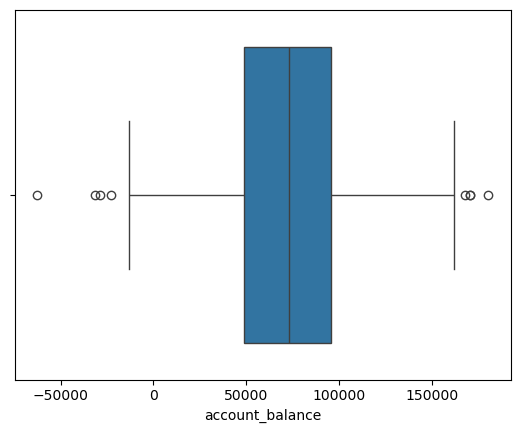

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
93,20,CUST7028,ACC11837,Current,Transfer,Home Loan,Firm D,South,Manager 1,2023-06-20,116567.53450,170593.81910,0.681410,518,196
158,190,CUST6292,ACC26940,Current,Transfer,Savings Account,Firm A,South,Manager 2,2023-07-17,86937.69692,-22668.04667,0.699954,417,92
362,63,CUST9564,ACC45907,Credit,Payment,Savings Account,Firm A,East,Manager 3,2023-06-06,75772.66434,170505.53430,0.541663,621,44
416,76,CUST4595,ACC32212,Savings,Transfer,Personal Loan,Firm B,North,Manager 4,2024-02-04,42862.98663,-28676.45255,0.558000,745,63
507,71,CUST1609,ACC19156,Savings,Withdrawal,Savings Account,Firm A,West,Manager 1,2024-06-11,62369.77560,-31233.11493,0.712639,461,188
520,142,CUST6837,ACC97411,Credit,Payment,Personal Loan,Firm B,North,Manager 2,2023-12-24,123364.04070,-62548.72206,0.500649,413,174
555,173,CUST2067,ACC10117,Current,Transfer,Personal Loan,Firm D,East,Manager 1,2023-04-30,77018.97098,180539.28770,0.396153,393,45
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.17885,168048.03330,0.546988,407,30


In [84]:
outliers('account_balance')

#### Risk score

IQR 0.32052814150000003
upper_limit 1.113591277
lower_limit -0.16852128900000002
NO. of outliers in risk_score  =  8


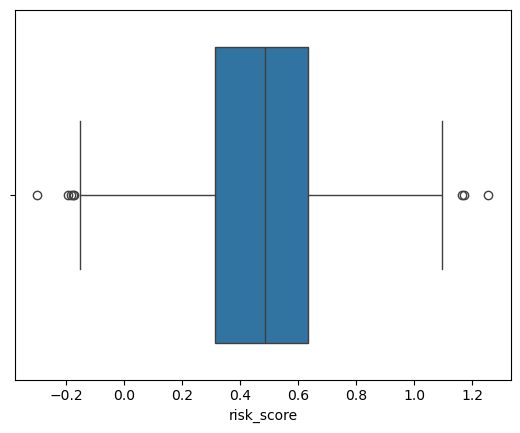

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
151,168,CUST4855,ACC20297,Credit,Payment,Savings Account,Firm C,East,Manager 2,2023-07-14,16605.54084,49950.23500,1.169362,385,60
156,166,CUST5500,ACC37688,Credit,Withdrawal,Mutual Fund,Firm A,West,Manager 1,2023-01-13,78848.11072,94355.90580,-0.300118,634,62
324,142,CUST2915,ACC89098,Credit,Withdrawal,Mutual Fund,Firm B,East,Manager 4,2023-02-17,49583.69455,79130.24761,-0.172534,825,139
328,44,CUST1189,ACC28305,Credit,Transfer,Home Loan,Firm B,East,Manager 3,2023-04-11,48914.49445,42583.58780,-0.176631,778,131
468,154,CUST2443,ACC67701,Current,Transfer,Credit Card,Firm D,West,Manager 4,2023-04-26,45869.29763,148156.21480,1.254704,722,197
577,36,CUST4794,ACC29477,Current,Deposit,Home Loan,Firm B,North,Manager 1,2023-03-08,18812.19933,73282.14537,-0.185899,514,53
608,29,CUST7933,ACC34431,Credit,Payment,Mutual Fund,Firm C,North,Manager 2,2024-06-22,48325.35238,162089.40380,1.162704,441,29
699,113,CUST1749,ACC55729,Current,Transfer,Personal Loan,Firm E,West,Manager 4,2024-05-22,67285.01337,63686.77576,-0.196231,447,79


In [85]:
outliers('risk_score')

#### Credit rating

IQR 262.5
upper_limit 1093.25
lower_limit 43.25
NO. of outliers in credit_rating  =  0


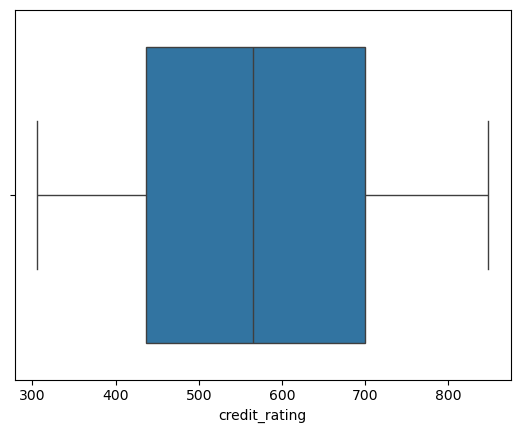

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month


In [86]:
outliers('credit_rating')

#### tenure_month

IQR 115.0
upper_limit 350.5
lower_limit -109.5
NO. of outliers in tenure_month  =  0


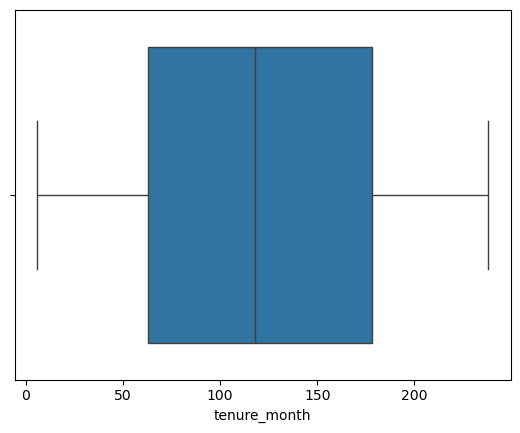

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month


In [87]:
outliers('tenure_month')

### ● Highlight customers with irregular or suspicious transaction behavior. 


IQR 39887.38711000001
upper_limit 134560.63202250004
lower_limit -24988.91641750002
NO. of outliers in transaction_amount  =  5


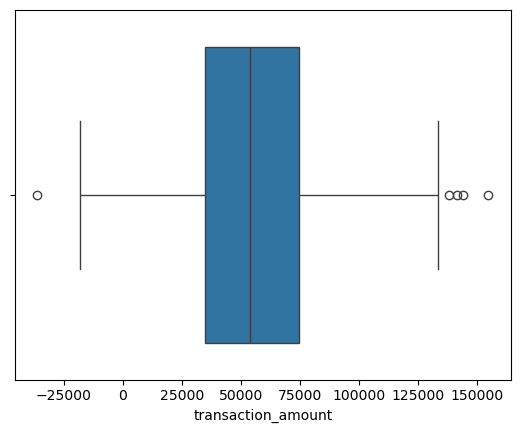

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
9,13,CUST2805,ACC19178,Credit,Payment,Credit Card,Firm D,West,Manager 3,2024-02-17,138133.82160,58667.17647,0.386822,747,126
161,52,CUST4258,ACC35419,Loan,Transfer,Personal Loan,Firm B,Central,Manager 1,2023-11-07,-36173.69555,24563.76881,0.838911,745,29
370,92,CUST6526,ACC77533,Loan,Transfer,Mutual Fund,Firm D,West,Manager 3,2024-02-17,154662.04580,68845.57535,0.696874,841,62
525,131,CUST4769,ACC92104,Current,Deposit,Mutual Fund,Firm B,East,Manager 1,2024-01-17,144137.88030,45084.92601,0.283584,364,231
533,47,CUST7098,ACC23736,Loan,Payment,Home Loan,Firm E,West,Manager 3,2023-09-28,141210.80340,94186.76562,0.885864,624,19


In [88]:
outliers('transaction_amount')

above are the customers with unusual transactions

# Task 5: Visualisation & EDA

## analysis of categorical columns

In [89]:
dt

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30


## analysis of account type

In [90]:
account_type = dt['account_type'].value_counts()
account_type

account_type
Credit     215
Loan       207
Savings    200
Current    178
Name: count, dtype: int64

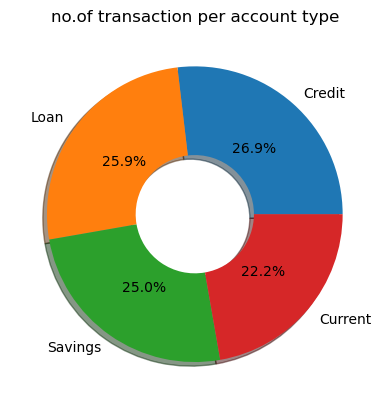

In [91]:
plt.pie(account_type,autopct='%0.1f%%',labels=account_type.index,shadow=True,wedgeprops=dict(width=0.6))
plt.title('no.of transaction per account type')
plt.show()

in above pie chart we can see that credit accounts has the highest proportion if transactions, also in the following barchart we can see that avg account balance is also highest in credit accounts

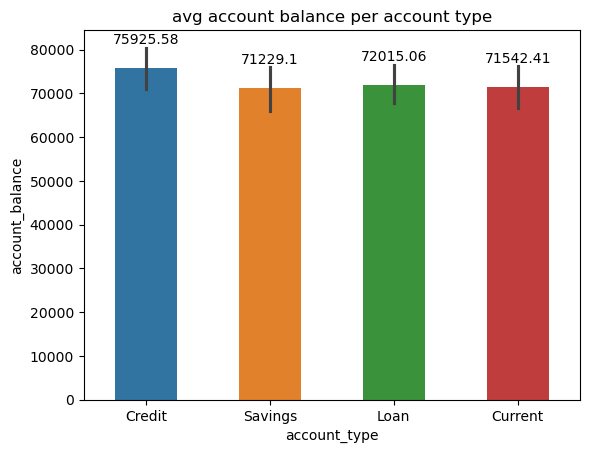

In [92]:
ax=sns.barplot(data=dt, y='account_balance',x='account_type',width=0.5,hue='account_type')
for i in ax.patches:
    ax.annotate(str(round(i.get_height(),2)),(i.get_x()+i.get_width()/2,i.get_height()+5500),ha='center')
ax.set_title('avg account balance per account type');

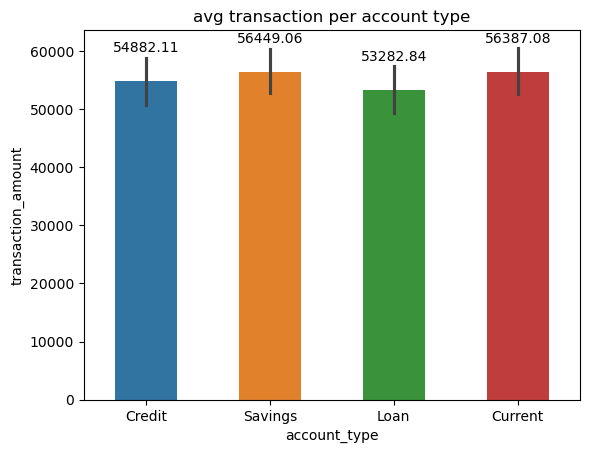

In [93]:
ax=sns.barplot(data=dt, y='transaction_amount',x='account_type',width=0.5,hue='account_type')
for i in ax.patches:
    ax.annotate(str(round(i.get_height(),2)),(i.get_x()+i.get_width()/2,i.get_height()+5000),ha='center')
ax.set_title('avg transaction per account type');

in above pie chart we can see that credit accounts has the highest proportion in transactions count. but if we see avg transaction amount, it is highest in current accounts, also in the barchart we can see that avg account balance is also highest in credit accounts

## analysis of transaction type

In [94]:
transaction_type = dt['transaction_type'].value_counts()
transaction_type

transaction_type
Deposit       205
Withdrawal    203
Payment       197
Transfer      195
Name: count, dtype: int64

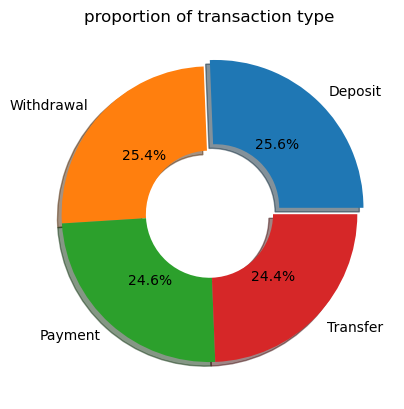

In [95]:
explode=[0.06,0,0,0]
plt.pie(transaction_type, autopct='%0.01f%%',labels=transaction_type.index,wedgeprops=dict(width=(0.57)),explode=explode,shadow=True)
plt.title('proportion of transaction type');

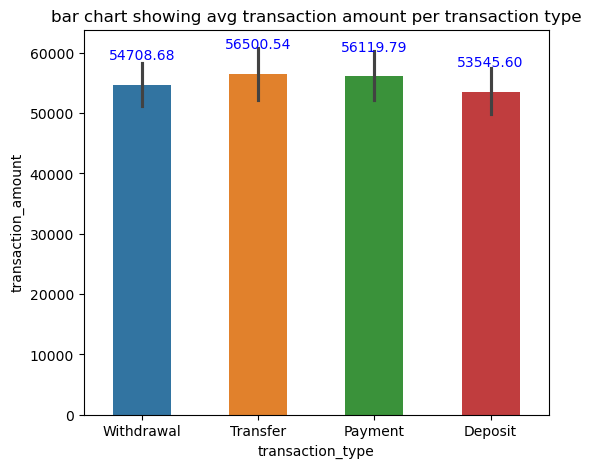

In [96]:
plt.figure(figsize=(6,5))
ax=sns.barplot(data=dt, x='transaction_type',y='transaction_amount',hue='transaction_type',width=0.5)
for containers in ax.containers:
    ax.bar_label(containers,fmt='%.2f',padding=16,color='blue')
plt.title('bar chart showing avg transaction amount per transaction type');

here we can see that 25%(highest) transactions are for deposit , but in terms of avg transaction amount lowest amount is in deposit section

## analysis of region

In [97]:
regions=dt['region'].value_counts()
regions

region
Central    175
South      166
West       160
North      151
East       148
Name: count, dtype: int64

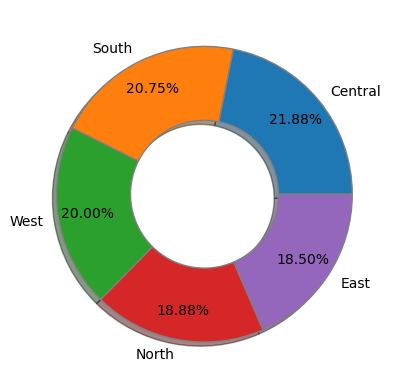

In [98]:
plt.pie(x=regions,autopct='%.2f%%',labels=regions.index,wedgeprops=dict(width=0.5,edgecolor='grey'),shadow=True,pctdistance=0.8);

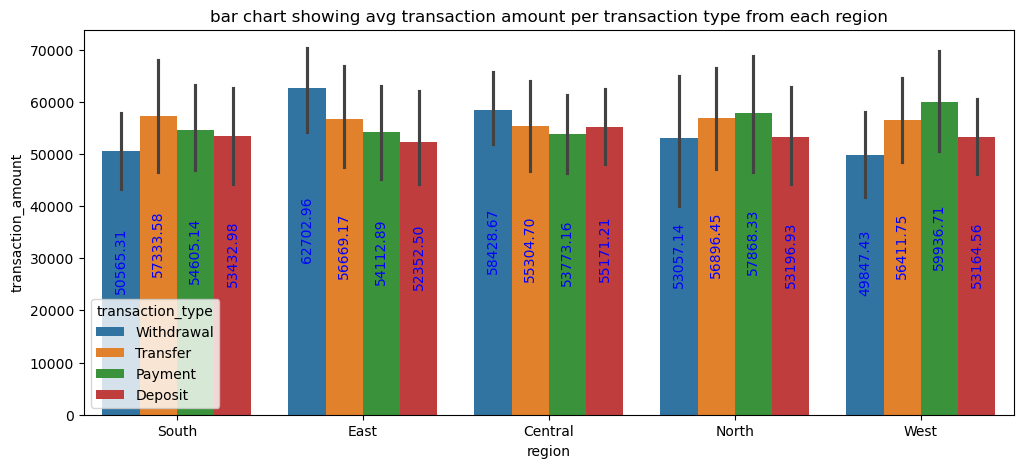

In [99]:
plt.figure(figsize=(12,5))
ax=sns.barplot(data=dt, x='region',y='transaction_amount',hue='transaction_type')
for containers in ax.containers:
    ax.bar_label(containers,fmt='%.2f',padding=16,color='blue',rotation='vertical',label_type='center')
plt.title('bar chart showing avg transaction amount per transaction type from each region');

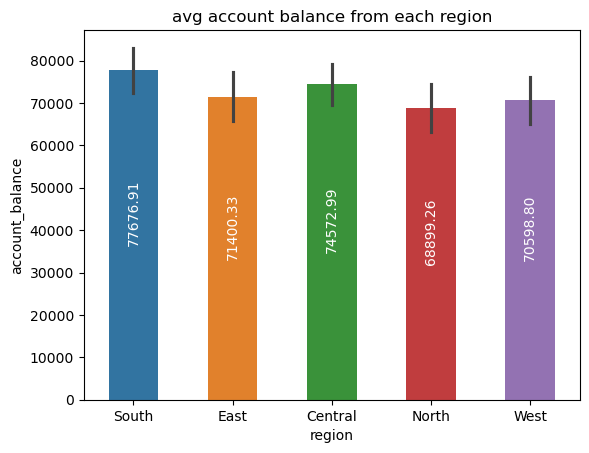

In [100]:
ax=sns.barplot(data=dt,x='region',y='account_balance',hue='region',width=0.5)
for i in ax.containers:
    ax.bar_label(i,fmt='%.2f',padding=16,label_type='center',rotation='vertical',color='white')
plt.title('avg account balance from each region');

***here central region has highest proportion in no. of transaction also the deposit is highest in cetral region***

## analysis of numerical columns

## univariate analysis

### analysis of transaction amount

In [101]:
dt

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30


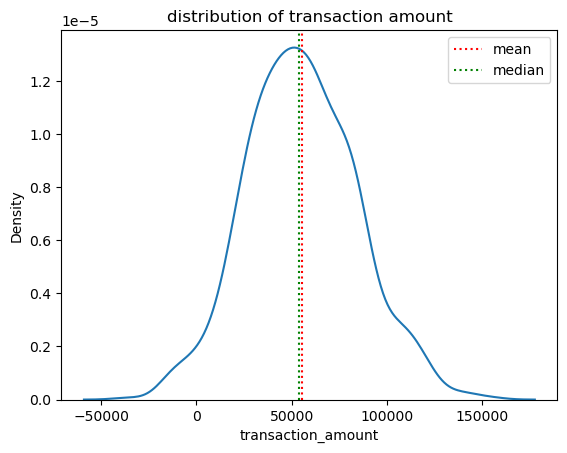

In [102]:
sns.kdeplot(data=dt, x='transaction_amount')
plt.axvline(x=dt['transaction_amount'].mean(),color='red',ls=':',label='mean')
plt.axvline(x=dt['transaction_amount'].median(),color='green',ls=':',label='median')
plt.title('distribution of transaction amount')
plt.legend();

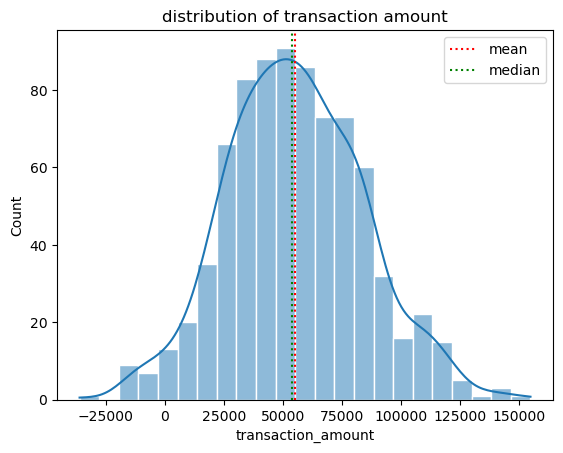

In [103]:
sns.histplot(x=dt['transaction_amount'],kde=True,edgecolor='white')
plt.axvline(x=dt['transaction_amount'].mean(),color='red',ls=':',label='mean')
plt.axvline(x=dt['transaction_amount'].median(),color='green',ls=':',label='median')
plt.title('distribution of transaction amount')
plt.legend();

***transaction amount is normaly distributed***

### analysis of balance amount

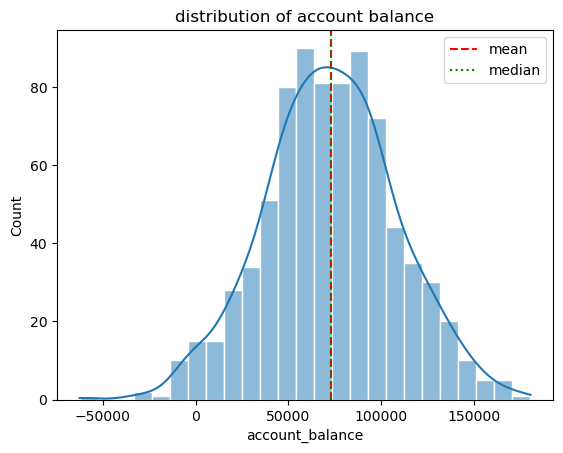

In [104]:
sns.histplot(x=dt['account_balance'], kde=True,edgecolor='white')
plt.axvline(x=dt['account_balance'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=dt['account_balance'].median(),color='green',ls=':',label='median')
plt.legend()
plt.title('distribution of account balance');

In [105]:
dt.account_balance.skew()

np.float64(-0.03357684399015441)

### distribution of risk score

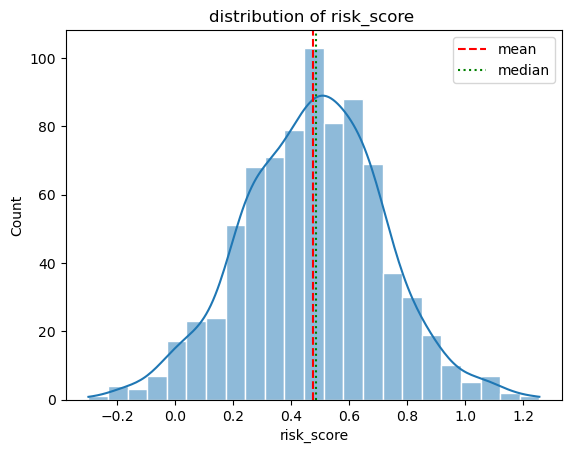

In [106]:
sns.histplot(x=dt['risk_score'], kde=True,edgecolor='white')
plt.axvline(x=dt['risk_score'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=dt['risk_score'].median(),color='green',ls=':',label='median')
plt.legend()
plt.title('distribution of risk_score ');

In [107]:
dt['risk_score'].skew()

np.float64(-0.04550102617973812)

### distribution of credit score

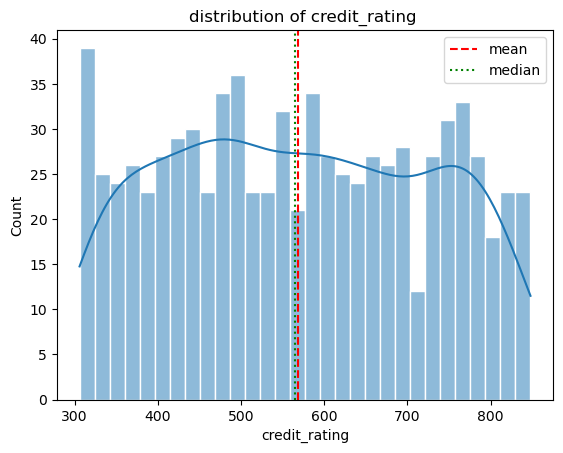

In [108]:
sns.histplot(x=dt['credit_rating'], kde=True,edgecolor='white',bins=30)
plt.axvline(x=dt['credit_rating'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=dt['credit_rating'].median(),color='green',ls=':',label='median')
plt.legend()
plt.title('distribution of credit_rating ');

In [109]:
dt['credit_rating'].skew()

np.float64(0.0465340814955236)

### distribution of credit score

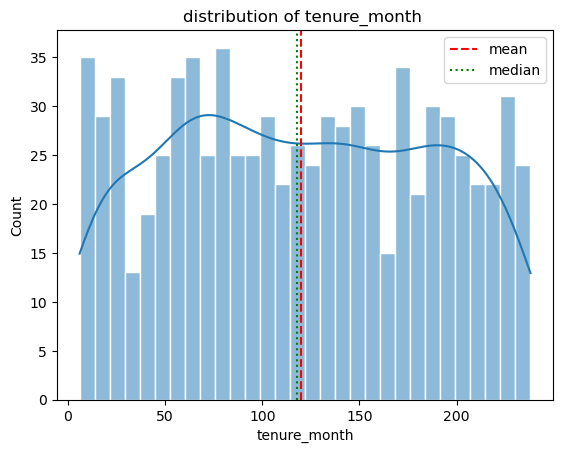

In [110]:
sns.histplot(x=dt['tenure_month'], kde=True,edgecolor='white',bins=30)
plt.axvline(x=dt['tenure_month'].mean(),color='red',ls='--',label='mean')
plt.axvline(x=dt['tenure_month'].median(),color='green',ls=':',label='median')
plt.legend()
plt.title('distribution of tenure_month ');

we can see that credit rating and tenure month is not normaly distribute , 

## Multivariate analysis

In [111]:
numarics = dt[['transaction_amount','account_balance','risk_score','credit_rating','tenure_month']]
numarics

,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
0,81300.425190,40843.56193,0.330474,484,13
1,9269.640373,61183.03953,0.089688,836,18
2,28138.552650,85460.13405,0.340010,451,25
3,83943.556980,100525.35900,0.605383,487,13
4,77104.456470,57425.69930,1.042441,393,10
...,...,...,...,...,...
795,74309.497130,61659.15894,0.425553,372,23
796,45859.598950,103267.73470,0.642004,401,104
797,458.484909,59361.15542,0.410000,667,139
798,31344.178850,168048.03330,0.546988,407,30


In [112]:
cor = numarics.corr()
cor

,transaction_amount,account_balance,risk_score,credit_rating,tenure_month
transaction_amount,1.000000,-0.002435,0.045661,0.007291,-0.009755
account_balance,-0.002435,1.000000,0.004931,0.021333,-0.036294
risk_score,0.045661,0.004931,1.000000,-0.013051,0.032964
credit_rating,0.007291,0.021333,-0.013051,1.000000,0.007603
tenure_month,-0.009755,-0.036294,0.032964,0.007603,1.000000


<Axes: >

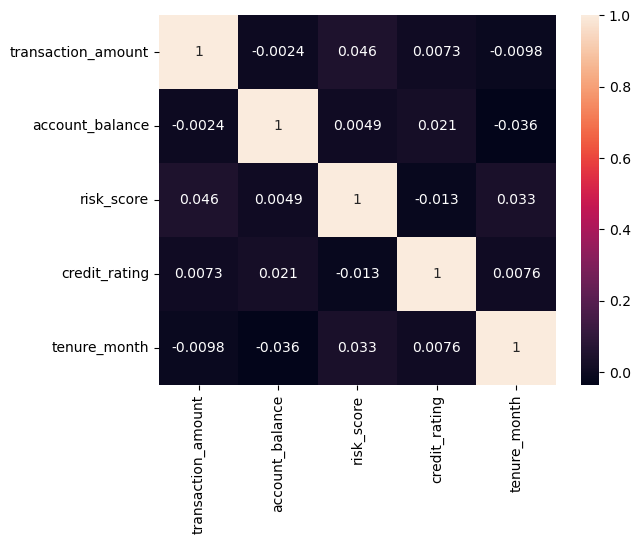

In [113]:
sns.heatmap(cor,annot=True)

### relation between account balance and risk score

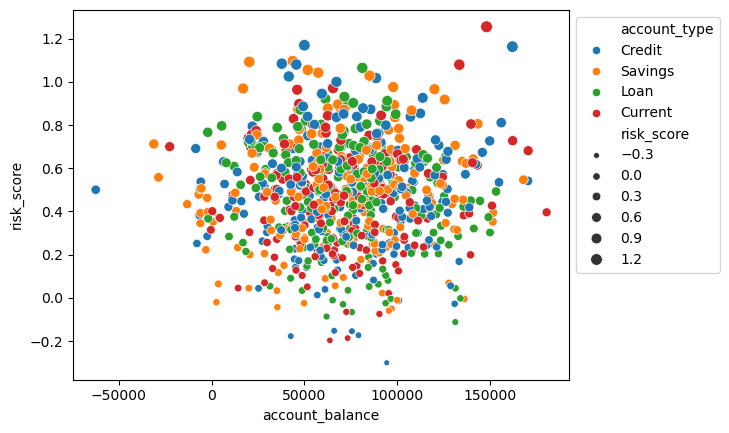

In [114]:
ax=sns.scatterplot(data=dt, x='account_balance', y='risk_score',size='risk_score',hue='account_type')
sns.move_legend(ax,'upper left',bbox_to_anchor=(1,1))


##### there isnt any sginificant relation between any of the columns

# Task 6: Hypothesis Testing 

## ● Testing whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.

In [115]:
#we have already categorised the accounts based on there transaction volume
txn_volume

,account_id,transaction_amount,category
0,ACC10117,599629.0,high
1,ACC10996,506746.0,high
2,ACC11062,247384.0,mid
3,ACC11188,127635.0,low
4,ACC11285,169319.0,low
...,...,...,...
184,ACC96868,317559.0,high
185,ACC97411,304243.0,high
186,ACC99117,116277.0,low
187,ACC99409,60447.0,low


In [116]:
# need to merge the category column to main data
dt2=dt.merge(txn_volume[['account_id','category']], on='account_id',how='left')
dt2

,transaction_id,customer_id,account_id,account_type,transaction_type,product,firm,region,manager,transaction_date,transaction_amount,account_balance,risk_score,credit_rating,tenure_month,category
0,78,CUST1223,ACC33287,Credit,Withdrawal,Savings Account,Firm E,South,Manager 4,2023-01-06,81300.425190,40843.56193,0.330474,484,13,high
1,21,CUST8266,ACC58667,Savings,Withdrawal,Credit Card,Firm A,South,Manager 2,2023-02-17,9269.640373,61183.03953,0.089688,836,18,high
2,176,CUST9420,ACC99117,Credit,Transfer,Home Loan,Firm A,East,Manager 1,2023-09-13,28138.552650,85460.13405,0.340010,451,25,low
3,167,CUST5253,ACC10117,Loan,Payment,Mutual Fund,Firm D,Central,Manager 1,2024-05-28,83943.556980,100525.35900,0.605383,487,13,high
4,46,CUST1223,ACC74631,Savings,Deposit,Credit Card,Firm A,East,Manager 4,2023-05-12,77104.456470,57425.69930,1.042441,393,10,mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,131,CUST3015,ACC96277,Savings,Transfer,Home Loan,Firm A,North,Manager 1,2024-01-01,74309.497130,61659.15894,0.425553,372,23,mid
796,158,CUST5558,ACC80131,Current,Transfer,Mutual Fund,Firm E,West,Manager 1,2023-05-12,45859.598950,103267.73470,0.642004,401,104,mid
797,132,CUST7345,ACC37688,Savings,Transfer,Personal Loan,Firm C,East,Manager 1,2024-03-22,458.484909,59361.15542,0.410000,667,139,low
798,28,CUST8028,ACC61827,Savings,Transfer,Credit Card,Firm A,South,Manager 3,2024-03-21,31344.178850,168048.03330,0.546988,407,30,mid


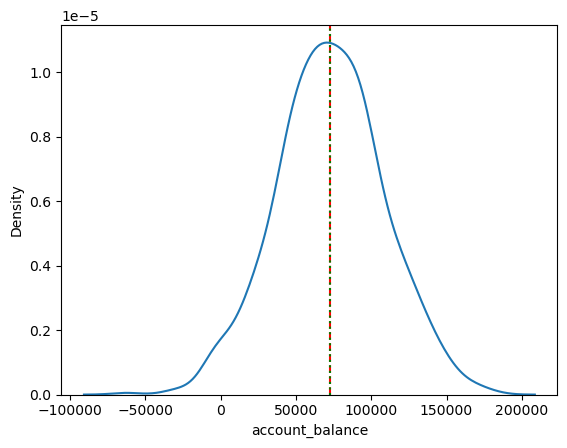

In [117]:
sns.kdeplot(data=dt2, x='account_balance')
plt.axvline(x=dt2['account_balance'].mean(),ls='--',color='red',label='mean')
plt.axvline(x=dt2['account_balance'].median(),ls='dotted',color='green',label='median')

In [118]:
dt2['account_balance'].skew()

np.float64(-0.03357684399015441)

***account balance is almost normaly distributed***

## seperating high volume and low volume data and their account_balance

In [119]:
high_vol= dt2[dt2['category']=='high'][['account_id','account_balance']]
high_vol_accounts=high_vol.groupby('account_id')['account_balance'].mean().reset_index()

In [120]:
high_vol_accounts.describe()

,account_balance
count,47.000000
mean,72101.231883
std,11861.112718
min,32190.912745
25%,65995.716835
50%,72285.891054
75%,78328.065472
max,102331.932205


In [121]:
low_vol= dt2[dt2['category']=='low'][['account_id','account_balance']]
low_vol_accounts=low_vol.groupby('account_id')['account_balance'].mean().reset_index()
low_vol_accounts.describe()

,account_balance
count,94.000000
mean,69837.098212
std,22499.074581
min,7017.436865
25%,55841.358359
50%,68259.938730
75%,86474.123198
max,117133.776550


### conducting hypothesis testing

***as we have to compare mean of two different groups so we need to use two sample t-test***

In [122]:
from scipy.stats import ttest_ind

**H0 = mean of high_vol_accounts are not greater than low_vol_accounts
(mean of high_val_account=mean of low_val_accounts, or mean of high_val_account < mean of low_val_accounts)**

**Ha= mean of high_val_accounts > mean of low_val_accounts**


**significance lavel = 0.05**

In [123]:
t_val, p_val = ttest_ind(high_vol_accounts['account_balance'],low_vol_accounts['account_balance'],equal_var=False,alternative='greater')

In [124]:
print('t_value',t_val)
print('p_value',p_val)

t_value 0.7822013389567555
p_value 0.2177154328133169


In [125]:
alpha= 0.05
if p_val<alpha:
    print('reject null hypo')
else:
    print('fail to reject null hypo')

fail to reject null hypo


***here we fail to reject the null hypothesis i.e mean of high_val_accunts is not significantly higher than mean of low_val_accounts***

## video link
https://drive.google.com/file/d/1gCm31OKmcnMNCpSSg6gfiOb5GSLm6MDa/view?usp=sharing